<a href="https://colab.research.google.com/github/HWu3150/python-compiler/blob/main/SSA_to_AST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numba
from numba import njit, jit, vectorize, prange
from numba.core.compiler import CompilerBase, DefaultPassBuilder
from numba.core.compiler_machinery import FunctionPass, register_pass
from numba.core.untyped_passes import *
from numba.core.typed_passes import *
from numba.core import ir, ir_utils, config, errors
import operator

import ast
import inspect
import re
import time
from IPython.display import display
from graphviz import Digraph

In [23]:
# Compiler pass that gets and stores Numba SSA statements
ssa_by_blocks = defaultdict(list)
blocks = {}
func_ir = None

@register_pass(mutates_CFG=False, analysis_only=True)
class GetSSAPass(FunctionPass):
  _name = "get_ssa"

  def __init__(self):
    FunctionPass.__init__(self)

  def run_pass(self, state):
    blocks.update(state.func_ir.blocks)
    global func_ir
    func_ir = state.func_ir
    for blk_offset, blk in state.func_ir.blocks.items():
      for stmt in blk.body:
        # Group SSA statements by block
        ssa_by_blocks[blk_offset].append(stmt)
    return False # analysis only

class GetSSACompiler(CompilerBase):

  def define_pipelines(self):
    pm = DefaultPassBuilder.define_nopython_pipeline(self.state)
    # pm.add_pass_after(GetSSAPass, ReconstructSSA)
    pm.add_pass_after(GetSSAPass, IRProcessing)
    pm.finalize()
    return [pm]

In [24]:
def get_ast(func):
    source = inspect.getsource(func)
    tree = ast.parse(source)
    print("AST Tree:", ast.dump(tree, indent=4))
    return tree

# visualize Python AST
def visualize_ast(node, graph=None, parent=None):
  if graph is None:
    graph = Digraph(comment="AST")

  # contex of the node, for example, Store(), Load()
  node.ctx = None

  node_id = str(id(node))
  label = type(node).__name__

  # set node name
  if isinstance(node, ast.Constant):
    label += f"\\n{node.value}"
  elif isinstance(node, ast.Name):
    label += f"\\n{node.id}"
  elif isinstance(node, ast.BinOp):
    label += f"\\n{type(node.op).__name__}"

  graph.node(node_id, label)

  # draw an edge between current node and its parent node
  if parent is not None:
    graph.edge(parent, node_id)

  # recursively draw childs of current node (draw subtrees)
  for child_name, child in ast.iter_fields(node):
    if isinstance(child, ast.AST):
      visualize_ast(child, graph, node_id)
    elif isinstance(child, list):
      for item in child:
        if isinstance(item, ast.AST):
          visualize_ast(item, graph, node_id)

  return graph

In [25]:
import graphviz
from numba import njit
from numba.core.compiler import run_frontend
from numba.core.analysis import compute_cfg_from_blocks

def visualize_cfg_with_analysis(blocks):
    cfg = compute_cfg_from_blocks(blocks)

    dot = graphviz.Digraph("ControlFlowGraph")

    # Add nodes (basic blocks)
    for block_offset, block in blocks.items():
        block_label = f"Block {block_offset}\\n"
        block_label += "\\n".join([str(stmt) for stmt in block.body])
        dot.node(str(block_offset), label=block_label, shape="box")

    # Add edges (control flow between blocks)
    for block_offset, _ in blocks.items():
        for succ, _ in cfg.successors(block_offset):
            dot.edge(str(block_offset), str(succ))

    # Render and display
    dot.render('cfg', format='png', cleanup=True)
    return dot

def cfg_viz(blocks):
  display(visualize_cfg_with_analysis(blocks))

SSA Statements Grouped by Block:
Block 0:
  x = const(int, 0)
  $const8.2 = const(int, 5)
  $10compare_op.3 = x < $const8.2
  bool12 = global(bool: <class 'bool'>)
  $12pred = call bool12($10compare_op.3, func=bool12, args=(Var($10compare_op.3, <ipython-input-26-89215395bf59>:4),), kws=(), vararg=None, varkwarg=None, target=None)
  branch $12pred, 14, 62
Block 14:
  $const16.1 = const(int, 2)
  $18binary_modulo.2 = x.3 % $const16.1
  $const20.3 = const(int, 0)
  $22compare_op.4 = $18binary_modulo.2 == $const20.3
  bool24 = global(bool: <class 'bool'>)
  $24pred = call bool24($22compare_op.4, func=bool24, args=(Var($22compare_op.4, <ipython-input-26-89215395bf59>:5),), kws=(), vararg=None, varkwarg=None, target=None)
  branch $24pred, 26, 46
Block 26:
  $const28.1 = const(int, 1)
  $30inplace_add.2 = inplace_binop(fn=<built-in function iadd>, immutable_fn=<built-in function add>, lhs=x.4, rhs=$const28.1, static_lhs=Undefined, static_rhs=Undefined)
  x = $30inplace_add.2
  $const36.4 = c

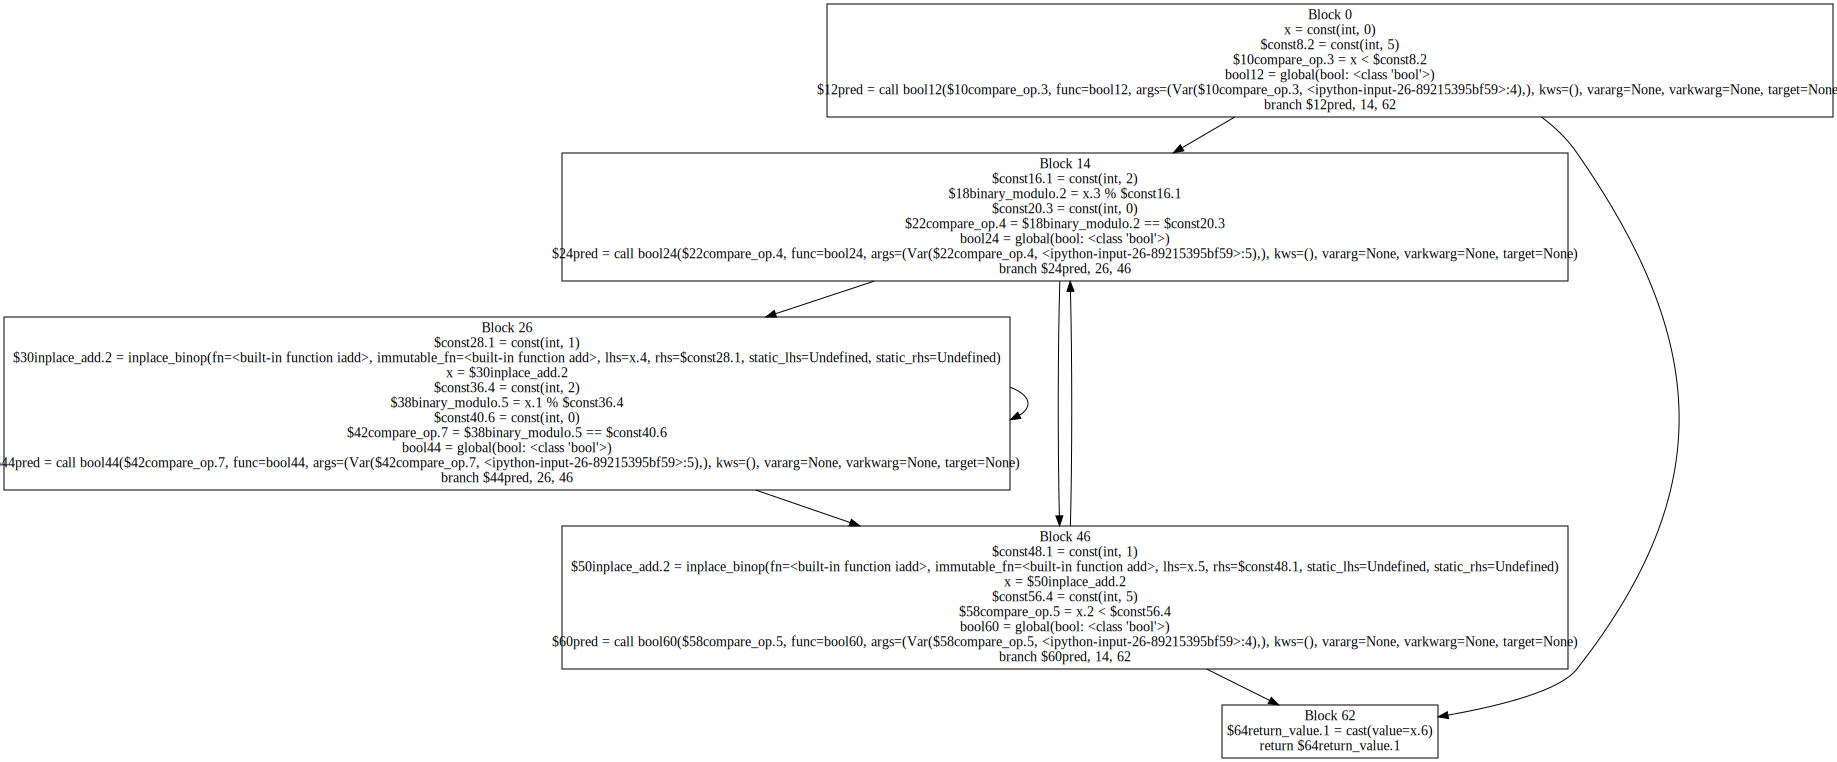

AST Tree: Module(
    body=[
        FunctionDef(
            name='test_loop',
            args=arguments(
                posonlyargs=[],
                args=[],
                kwonlyargs=[],
                kw_defaults=[],
                defaults=[]),
            body=[
                Assign(
                    targets=[
                        Name(id='x', ctx=Store())],
                    value=Constant(value=0)),
                While(
                    test=Compare(
                        left=Name(id='x', ctx=Load()),
                        ops=[
                            Lt()],
                        comparators=[
                            Constant(value=5)]),
                    body=[
                        While(
                            test=Compare(
                                left=BinOp(
                                    left=Name(id='x', ctx=Load()),
                                    op=Mod(),
                                    right=Constant

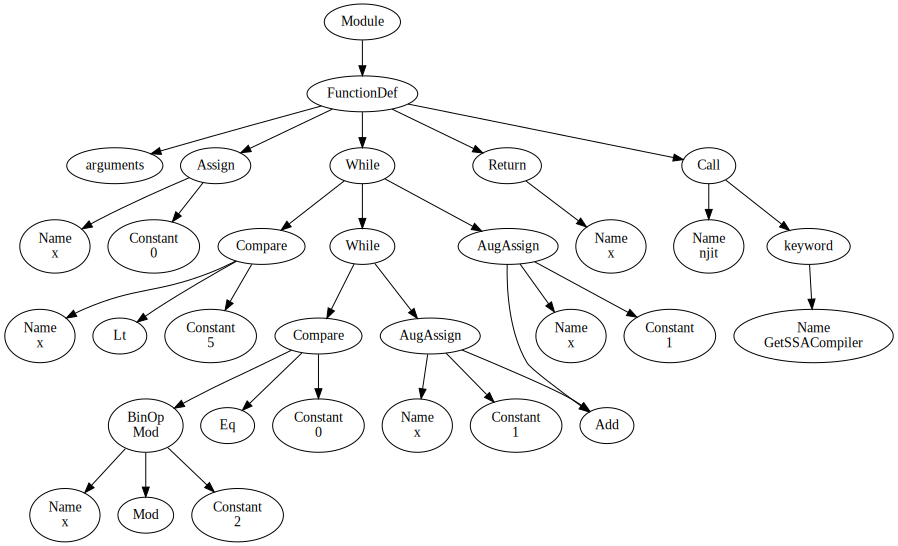

In [26]:
@njit(pipeline_class=GetSSACompiler)
def test_loop():
  x = 0
  while x < 5:
    while x % 2 == 0:
      x += 1
    x += 1
  return x

ssa_by_blocks.clear()
blocks.clear()
func_ir = None

test_loop()
print("SSA Statements Grouped by Block:")
for blk_offset, ssa_list in ssa_by_blocks.items():
  print(f"Block {blk_offset}:")
  for stmt in ssa_list:
    print(f"  {stmt}")
print()

cfg_viz(blocks)

display(visualize_ast(get_ast(test_loop)))

In [27]:
def live_analysis(blocks):
  """
  Compute LIVE-IN, LIVE-OUT sets and DEF, USE sets for each block in a CFG.

  Args:
  blocks: CFG blocks

  Returns:
  live_out: Dictionary mapping each block label to its LIVE-OUT set.
  def_sets: Dictionary mapping each block label to its DEF set.
  """
  cfg = compute_cfg_from_blocks(blocks)

  # Initialize LIVE-IN, LIVE-OUT, and DEF, USE sets
  live_in = defaultdict(set)
  live_out = defaultdict(set)
  def_sets = defaultdict(set)
  use_sets = defaultdict(set)

  # Helper functions to extract used variables
  def vars_used(stmt):
      return {var.name for var in stmt.list_vars()} if hasattr(stmt, 'list_vars') else set()

  # Helper functions to extract defined variables
  def vars_defined(stmt):
      return {stmt.target.name} if isinstance(stmt, ir.Assign) else set()

  # Step 1: Compute DEF and USE sets for each block
  for label, block in blocks.items():
      for stmt in block.body:
          def_sets[label] |= vars_defined(stmt)
          use_sets[label] |= vars_used(stmt) - def_sets[label]  # Exclude variables already defined in this block

  # Step 1.5: Compute set of all variables
  all_vars = set().union(*(def_sets[label] for label, _ in blocks.items()))

  # Step 2: Iterative computation of LIVE-IN and LIVE-OUT sets
  changed = True
  while changed:
    changed = False
    for label, block in blocks.items():
      # Compute LIVE-OUT as union of successors' LIVE-IN
      new_live_out = set().union(*(live_in[succ] for succ, _ in cfg.successors(label)))

      # Compute LIVE-IN as USE + (LIVE-OUT - DEF)
      new_live_in = use_sets[label] | (new_live_out - def_sets[label])

      # Check if LIVE-IN or LIVE-OUT changed
      if new_live_in != live_in[label] or new_live_out != live_out[label]:
        live_in[label] = new_live_in
        live_out[label] = new_live_out
        changed = True

  return live_in, live_out, def_sets, all_vars

In [28]:
def is_loop_entry(label, loops):
  for _, loop in loops.items():
    if label in loop.entries:
      return True
  return False

def is_in_any_loop(label, loops):
  for _, loop in loops.items():
    if label in loop.entries or label in loop.body:
      return True
  return False

def compute_unnecessary_variables(block, label, loops):
  """
  Fold unnecessary statements in the given blocks.

  Args:
  SSA blocks
  label of the block
  Loops: A dictionary mapping loop headers to loop information.

  Returns:
  Set of unnecessary variables
  """
  unnecessary_vars = set()

  if is_loop_entry(label, loops):
    return unnecessary_vars

  if not is_in_any_loop(label, loops):
    return unnecessary_vars

  unnecessary_vars.add(block.body[-1].cond)
  for i in range(-2, -len(block.body) - 1, -1):
    stmt = block.body[i]
    if stmt.target in unnecessary_vars:
      var_list = stmt.list_vars()
      for var in var_list:
        unnecessary_vars.add(var)
  return unnecessary_vars

In [29]:
compute_unnecessary_variables(blocks[26], 26, loops)

{Var($38binary_modulo.5, <ipython-input-26-89215395bf59>:5),
 Var($42compare_op.7, <ipython-input-26-89215395bf59>:5),
 Var($44pred, <ipython-input-26-89215395bf59>:5),
 Var($const36.4, <ipython-input-26-89215395bf59>:5),
 Var($const40.6, <ipython-input-26-89215395bf59>:5),
 Var(bool44, <ipython-input-26-89215395bf59>:5),
 Var(x.1, <ipython-input-26-89215395bf59>:6)}

In [30]:
import ast

def convert_stmt_to_node(stmt):
    """
    Args:
    SSA statement

    Returns:
    AST node representing the statement
    """
    inplace_ops = {
        operator.iadd: ast.Add(),
        operator.isub: ast.Sub(),
        operator.imul: ast.Mult(),
        operator.itruediv: ast.Div(),
        operator.imod: ast.Mod()
    }

    arithmetic_ops = {
        operator.add: ast.Add(),
        operator.sub: ast.Sub(),
        operator.mul: ast.Mult(),
        operator.truediv: ast.Div(),
        operator.floordiv: ast.FloorDiv(),
        operator.mod: ast.Mod()
    }

    compare_ops = {
        operator.lt: ast.Lt(),
        operator.le: ast.LtE(),
        operator.eq: ast.Eq(),
        operator.ne: ast.NotEq(),
        operator.ge: ast.GtE(),
        operator.gt: ast.Gt()
    }

    # Assign
    if isinstance(stmt, ir.Assign):
      # Ignore Global

      if isinstance(stmt.value, ir.Var):
        return ast.Assign(
            targets=[ast.Name(id=stmt.target.name, ctx=ast.Store())],
            value=ast.Name(id=stmt.value.name, ctx=ast.Load()),
        )

      # R.H.S of Assign is Const
      elif isinstance(stmt.value, ir.Const):
        return ast.Assign(
            targets=[ast.Name(id=stmt.target.name, ctx=ast.Store())],
            value=ast.Constant(value=stmt.value.value),
        )

      # R.H.S of Assign is a binop
      elif isinstance(stmt.value, ir.Expr) and stmt.value.op == 'binop':
        # binop is an arithmetic operation
        if stmt.value.fn in arithmetic_ops:
          return ast.Assign(
              targets=[ast.Name(id=stmt.target.name, ctx=ast.Store())],
              value=ast.BinOp(
                  left=ast.Name(id=stmt.value.lhs.name, ctx=ast.Load()),
                  op=arithmetic_ops[stmt.value.fn],
                  right=ast.Name(id=stmt.value.rhs.name, ctx=ast.Load()),
              ),
          )
        # binop is a compare operation
        if stmt.value.fn in compare_ops:
          return ast.Assign(
              targets=[ast.Name(id=stmt.target.name, ctx=ast.Store())],
              value=ast.Compare(
                  left=ast.Name(id=stmt.value.lhs.name, ctx=ast.Load()),
                  ops=compare_ops[stmt.value.fn],
                  comparators=ast.Name(id=stmt.value.rhs.name, ctx=ast.Load()),
              ),
          )

      # R.H.S of Assign is inplace binop, e.g., x += 1 -> $tmp = inplace(add, x, 1)
      elif isinstance(stmt.value, ir.Expr) and stmt.value.op == 'inplace_binop':
        aug_assign = ast.AugAssign(
            target=ast.Name(id=stmt.value.lhs.name, ctx=ast.Store()),
            op=inplace_ops[stmt.value.fn],
            value=ast.Name(id=stmt.value.rhs.name, ctx=ast.Load()),
        )
        return ast.Assign(
            targets=[ast.Name(id=stmt.target.name, ctx=ast.Store())],
            value=aug_assign,
        )

      # Expr
      elif isinstance(stmt.value, ir.Expr) and stmt.value.op == 'cast':
        return ast.Assign(
            targets=[ast.Name(id=stmt.target.name, ctx=ast.Store())],
            value=ast.Name(id=stmt.value._kws['value'], ctx=ast.Load()),
        )

    # TODO, jump statement from if-else branch

    # Return
    elif isinstance(stmt, ir.Return):
      return ast.Return(
          value=ast.Name(id=stmt.value.name, ctx=ast.Load())
      )

    # Unsupported statement type
    return None


In [31]:
def convert_branch_to_ast(branch, cond_stmt_node):
  """
  Args:
  SSA branch statement
  Condition statement node

  Returns:
  AST node representing the branch statement
  """
  while_node = ast.While(
        test=cond_stmt_node.value,  # Right subtree of the condition statement node
        body=[],      # Loop body is the node converted from the body block
        orelse=[]
  )

  return while_node

In [32]:
def convert_block_to_ast(block, label, loops):
  """
  Args:
  SSA block
  label of the block
  Loops: A dictionary mapping loop headers to loop information.

  Returns:
  AST node representing the block
  """
  ast_nodes = list()
  unnecessary_vars = list()

  # Convert regular stmt into AST node
  unnecessary_vars = compute_unnecessary_variables(block, label, loops)
  for stmt in block.body:
    if isinstance(stmt, ir.Assign) and stmt.target in unnecessary_vars:
      continue
    if isinstance(stmt, ir.Branch) and stmt.cond in unnecessary_vars:
      continue
    ast_node = convert_stmt_to_node(stmt)
    if ast_node is not None:
      ast_nodes.append(ast_node)

  # Deal with Branch statement
  # Branch could be in loop entry or body
  # Branch must be in the last line in a block
  if isinstance(block.body[-1], ir.Branch):
    # If the block is loop entry
    for _, loop in loops.items():
      if label in loop.entries:
        cond_stmt_node = ast_nodes.pop()
        ast_nodes.append(convert_branch_to_ast(block.body[-1], cond_stmt_node))

  return ast_nodes

In [33]:
def insert_temporary_node(label, ast_nodes):
  """
  For testing only. Insert a parent node for a list
  of AST nodes.

  Args:
  AST nodes of the block
  label of the block

  Returns:
  AST node
  """
  temp_node = ast.FunctionDef(
    name="Block {}".format(label),
    args=None,
    body=ast_nodes,
    decorator_list=[]
  )

  return temp_node

In [34]:
def construct_ast(blocks):
  """
  Args:
  SSA blocks

  Returns:
  AST node representing the program
  """
  cfg = compute_cfg_from_blocks(blocks)
  loops = cfg._find_loops()

  # Use LiveIn set to find function arguments
  # live_in, _, _, _ = live_analysis(blocks)

  # Compute AST node list of each block
  all_ast_nodes = defaultdict(list)
  for label, block in blocks.items():
    ast_nodes = convert_block_to_ast(block, label, loops)
    all_ast_nodes[label] = ast_nodes

  loop_body_of_entries = defaultdict(list)
  for _, loop in loops.items():
    for entry in loop.entries:
      loop_body_of_entries[entry] = loop.body

  # Compute dominator tree
  dom_tree = cfg.dominator_tree()

  for entry_label, body in sorted(loop_body_of_entries.items(), key=lambda x: x[0], reverse=True):
    dominated_blocks = dom_tree[entry_label]
    for label in dominated_blocks:
      if label in loop_body_of_entries[entry_label]:
        for node in all_ast_nodes[entry_label]:
          if isinstance(node, ast.While):
            node.body.extend(all_ast_nodes[label])
      else:
        all_ast_nodes[entry_label].extend(all_ast_nodes[label])


  # Function arguments
  args = ast.arguments(
      posonlyargs=[],
      args=[],
      vararg=None,
      kwonlyargs=[],
      kw_defaults=[],
      kwarg=None,
      defaults=[]
  )

  # Function body
  body = all_ast_nodes[0]

  # Function node
  func_def = ast.FunctionDef(
      name="func",
      args=args,
      body=body,
      decorator_list=[],
      returns=None
  )

  # Root node
  module = ast.Module(
      body=[func_def],
      type_ignores=[]
  )

  return module

x = const(int, 0)


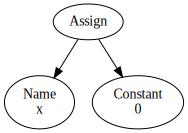

$const8.2 = const(int, 5)


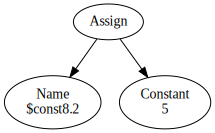

$10compare_op.3 = x < $const8.2


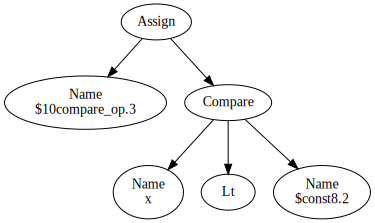

bool12 = global(bool: <class 'bool'>)
$12pred = call bool12($10compare_op.3, func=bool12, args=(Var($10compare_op.3, <ipython-input-26-89215395bf59>:4),), kws=(), vararg=None, varkwarg=None, target=None)
branch $12pred, 14, 62


In [35]:
stmts = blocks[0].body
for stmt in stmts:
  print(stmt)
  node = convert_stmt_to_node(stmt)
  if node is not None:
    display(visualize_ast(node))

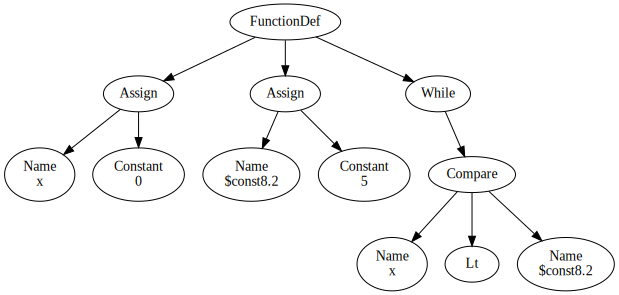

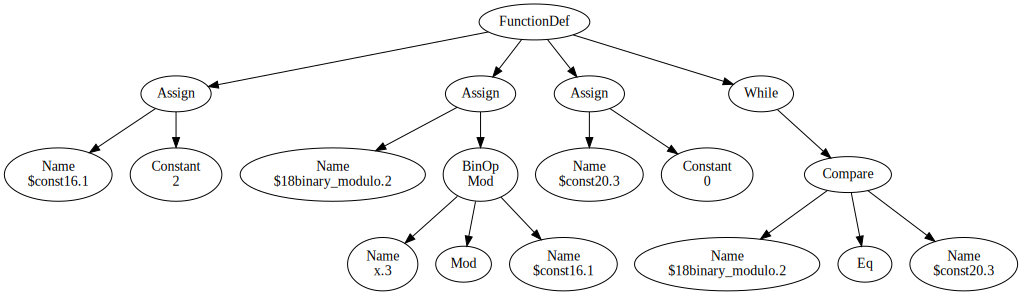

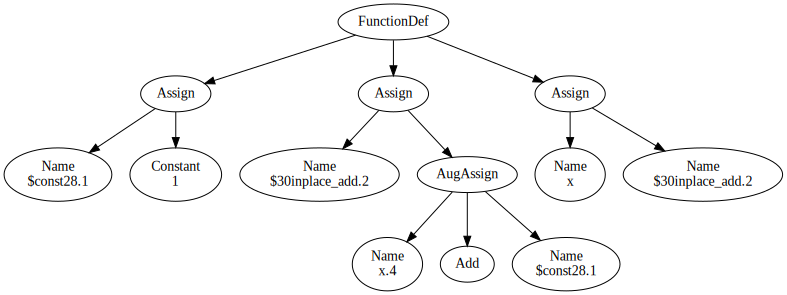

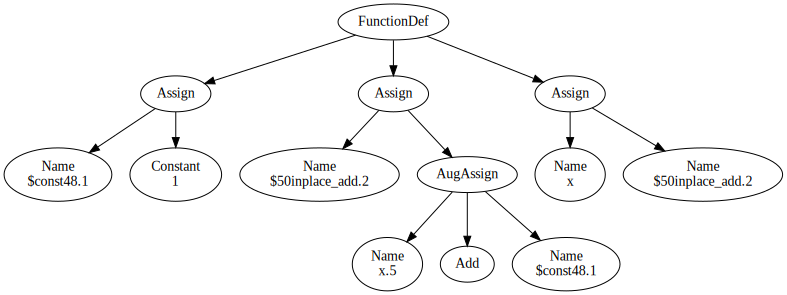

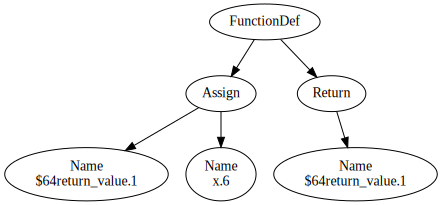

In [36]:
for label, block in blocks.items():
  display(visualize_ast(insert_temporary_node(label, convert_block_to_ast(block, label, loops))))

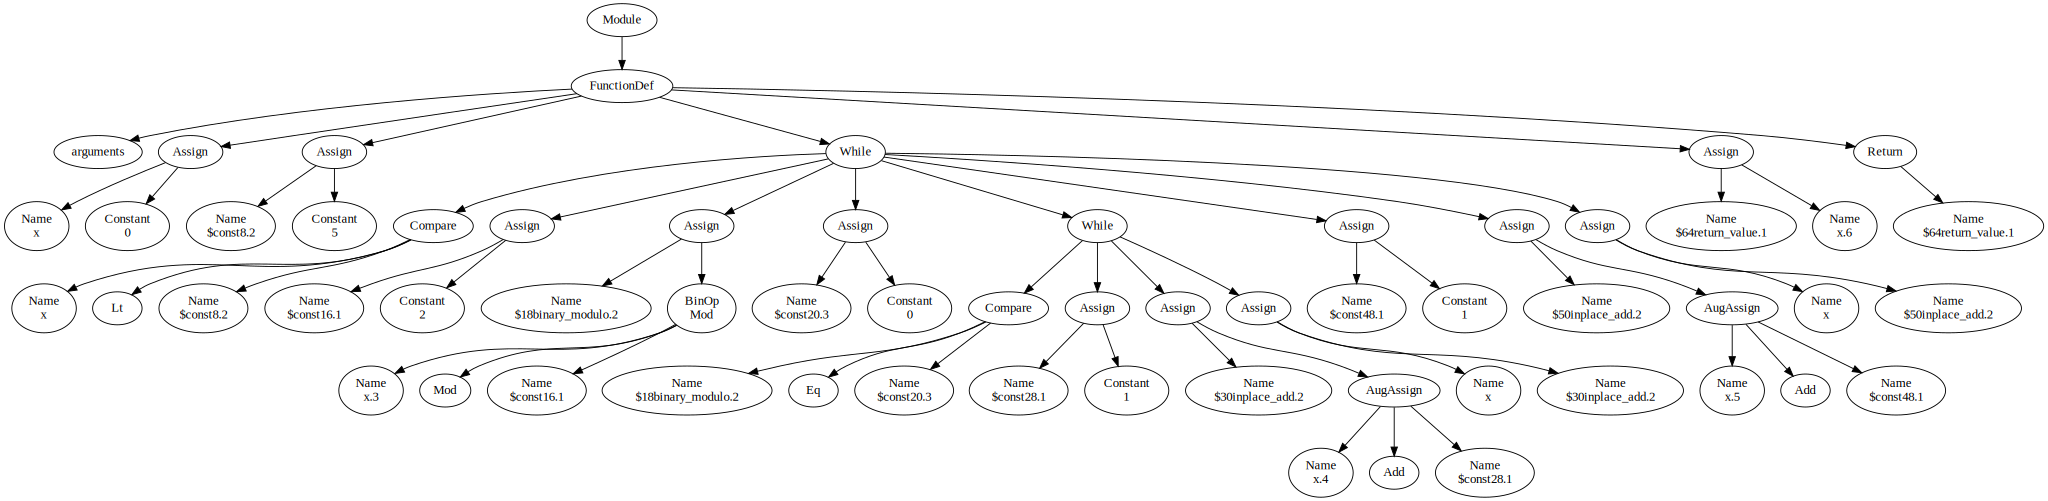

In [37]:
astree = construct_ast(blocks)
display(visualize_ast(astree))

```Python
def f():
  x = 0
  $const8.2 = 5
  while x < $const8.2:
    $const16.1 = 2
    $18binary_modulo.2 = x.3 % $cosnt16.1
    $const20.3 = 0
    while $18binary_modulo.2 == $const20.3:
      $const28.1 = 1
      $30inplace_add.2 = x.4 += $const28.1
      x = $30inplace_add.2
    $const48.1 = 1
    $50inplace_add.2 = x.5 += $const48.1
    x = $50inplace_add.2
  $64return_value.1 = x.6
  return $64return_value.1
```



SSA Statements Grouped by Block:
Block 0:
  x = const(int, 0)
  $const8.2 = const(int, 5)
  $10compare_op.3 = x < $const8.2
  bool12 = global(bool: <class 'bool'>)
  $12pred = call bool12($10compare_op.3, func=bool12, args=(Var($10compare_op.3, <ipython-input-38-1136f9235a69>:4),), kws=(), vararg=None, varkwarg=None, target=None)
  branch $12pred, 14, 118
Block 14:
  $const16.1 = const(int, 2)
  $18binary_modulo.2 = x.5 % $const16.1
  $const20.3 = const(int, 0)
  $22compare_op.4 = $18binary_modulo.2 == $const20.3
  bool24 = global(bool: <class 'bool'>)
  $24pred = call bool24($22compare_op.4, func=bool24, args=(Var($22compare_op.4, <ipython-input-38-1136f9235a69>:5),), kws=(), vararg=None, varkwarg=None, target=None)
  branch $24pred, 26, 70
Block 26:
  $const28.1 = const(int, 3)
  $30compare_op.2 = x.6 < $const28.1
  bool32 = global(bool: <class 'bool'>)
  $32pred = call bool32($30compare_op.2, func=bool32, args=(Var($30compare_op.2, <ipython-input-38-1136f9235a69>:6),), kws=(), varar

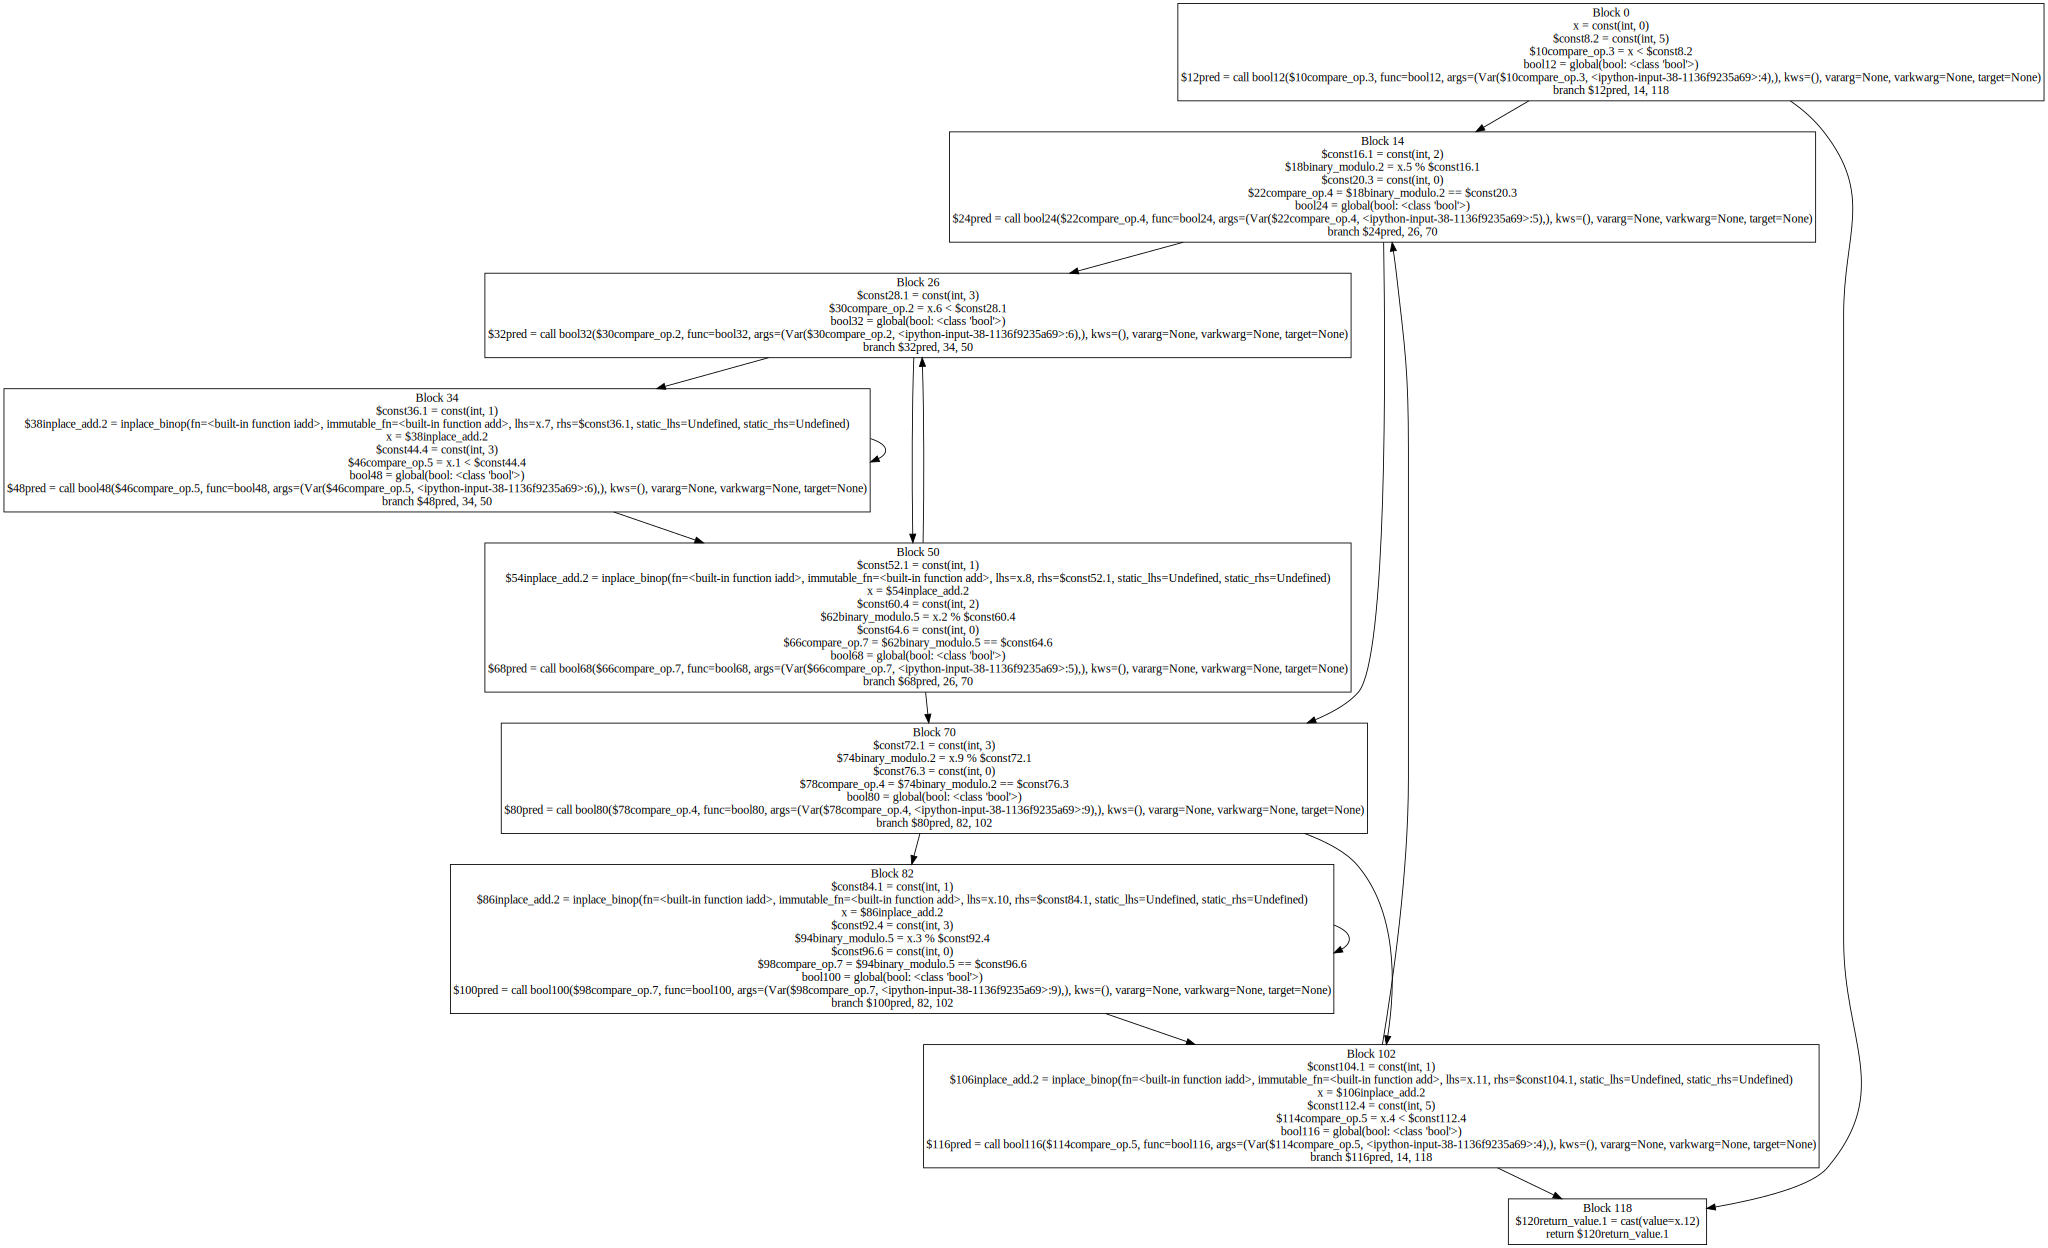

AST Tree: Module(
    body=[
        FunctionDef(
            name='test_loop_2',
            args=arguments(
                posonlyargs=[],
                args=[],
                kwonlyargs=[],
                kw_defaults=[],
                defaults=[]),
            body=[
                Assign(
                    targets=[
                        Name(id='x', ctx=Store())],
                    value=Constant(value=0)),
                While(
                    test=Compare(
                        left=Name(id='x', ctx=Load()),
                        ops=[
                            Lt()],
                        comparators=[
                            Constant(value=5)]),
                    body=[
                        While(
                            test=Compare(
                                left=BinOp(
                                    left=Name(id='x', ctx=Load()),
                                    op=Mod(),
                                    right=Consta

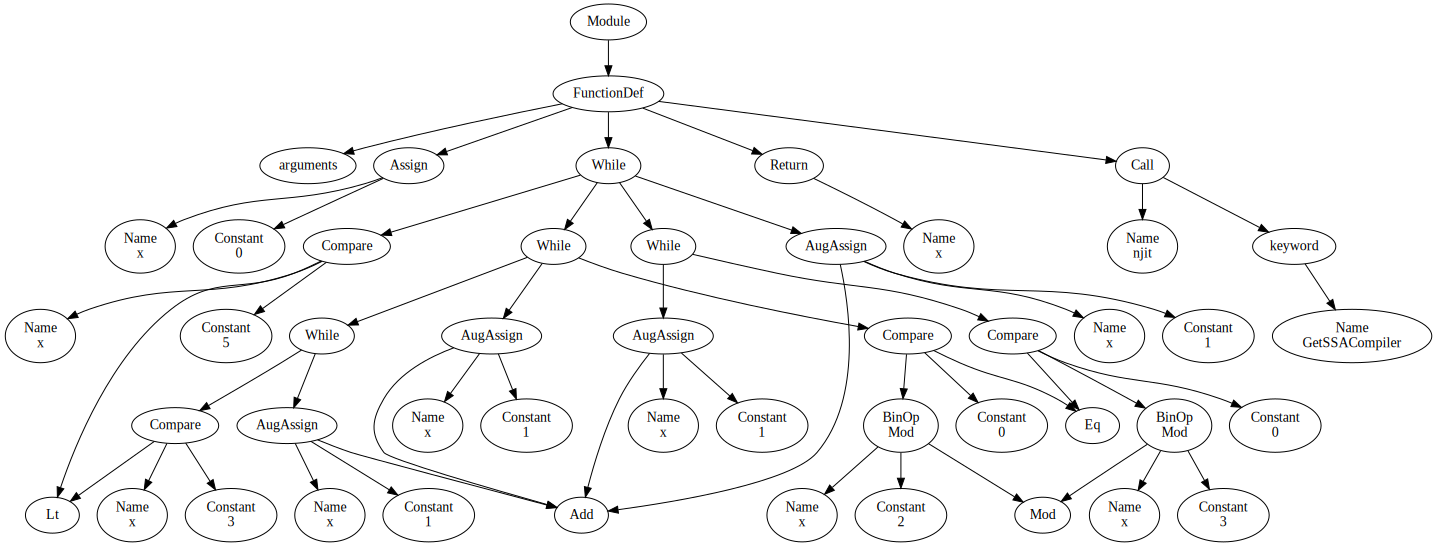

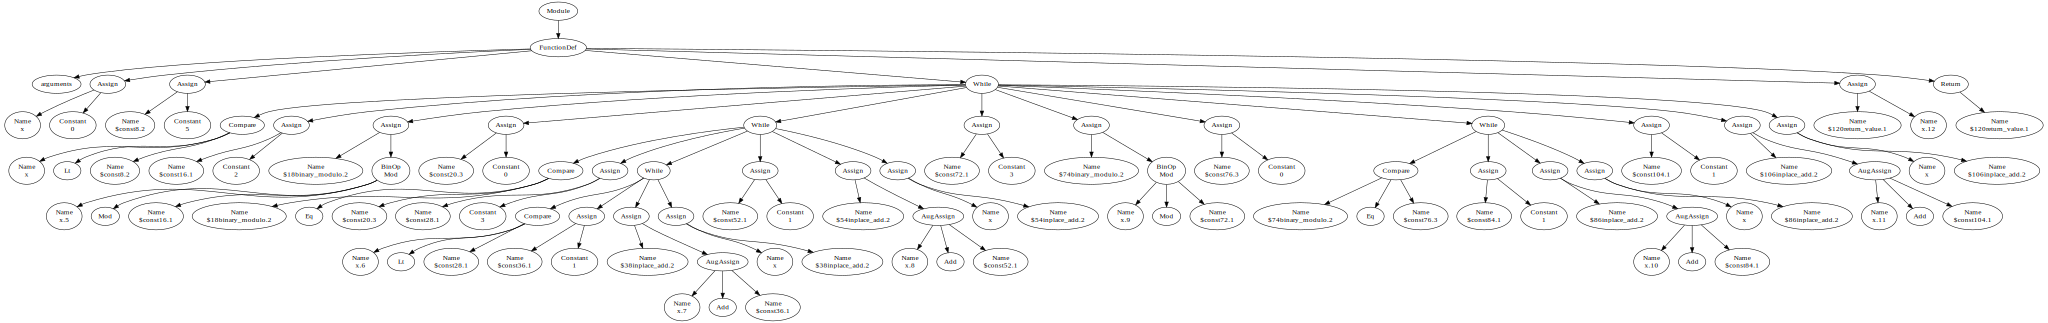

In [38]:
@njit(pipeline_class=GetSSACompiler)
def test_loop_2():
  x = 0
  while x < 5:
    while x % 2 == 0:
      while x < 3:
        x += 1
      x += 1
    while x % 3 == 0:
      x += 1
    x += 1
  return x

ssa_by_blocks.clear()
blocks.clear()
func_ir = None

test_loop_2()
print("SSA Statements Grouped by Block:")
for blk_offset, ssa_list in ssa_by_blocks.items():
  print(f"Block {blk_offset}:")
  for stmt in ssa_list:
    print(f"  {stmt}")
print()

cfg_viz(blocks)

display(visualize_ast(get_ast(test_loop_2)))

astree = construct_ast(blocks)
display(visualize_ast(astree))
# print(ast.unparse(astree))

SSA Statements Grouped by Block:
Block 0:
  A = arg(0, name=A)
  B = arg(1, name=B)
  $2load_global.0 = global(np: <module 'numpy' from '/usr/local/lib/python3.10/dist-packages/numpy/__init__.py'>)
  $4load_method.1 = getattr(value=$2load_global.0, attr=zeros)
  $8load_attr.3 = getattr(value=A, attr=shape)
  $const10.4 = const(int, 0)
  $12binary_subscr.5 = getitem(value=$8load_attr.3, index=$const10.4, fn=<built-in function getitem>)
  $16load_attr.7 = getattr(value=B, attr=shape)
  $const18.8 = const(int, 1)
  $20binary_subscr.9 = getitem(value=$16load_attr.7, index=$const18.8, fn=<built-in function getitem>)
  $22build_tuple.10 = build_tuple(items=[Var($12binary_subscr.5, <ipython-input-39-e4dca537b79f>:15), Var($20binary_subscr.9, <ipython-input-39-e4dca537b79f>:15)])
  C = call $4load_method.1($22build_tuple.10, func=$4load_method.1, args=[Var($22build_tuple.10, <ipython-input-39-e4dca537b79f>:15)], kws=(), vararg=None, varkwarg=None, target=None)
  $28load_global.12 = global(rang

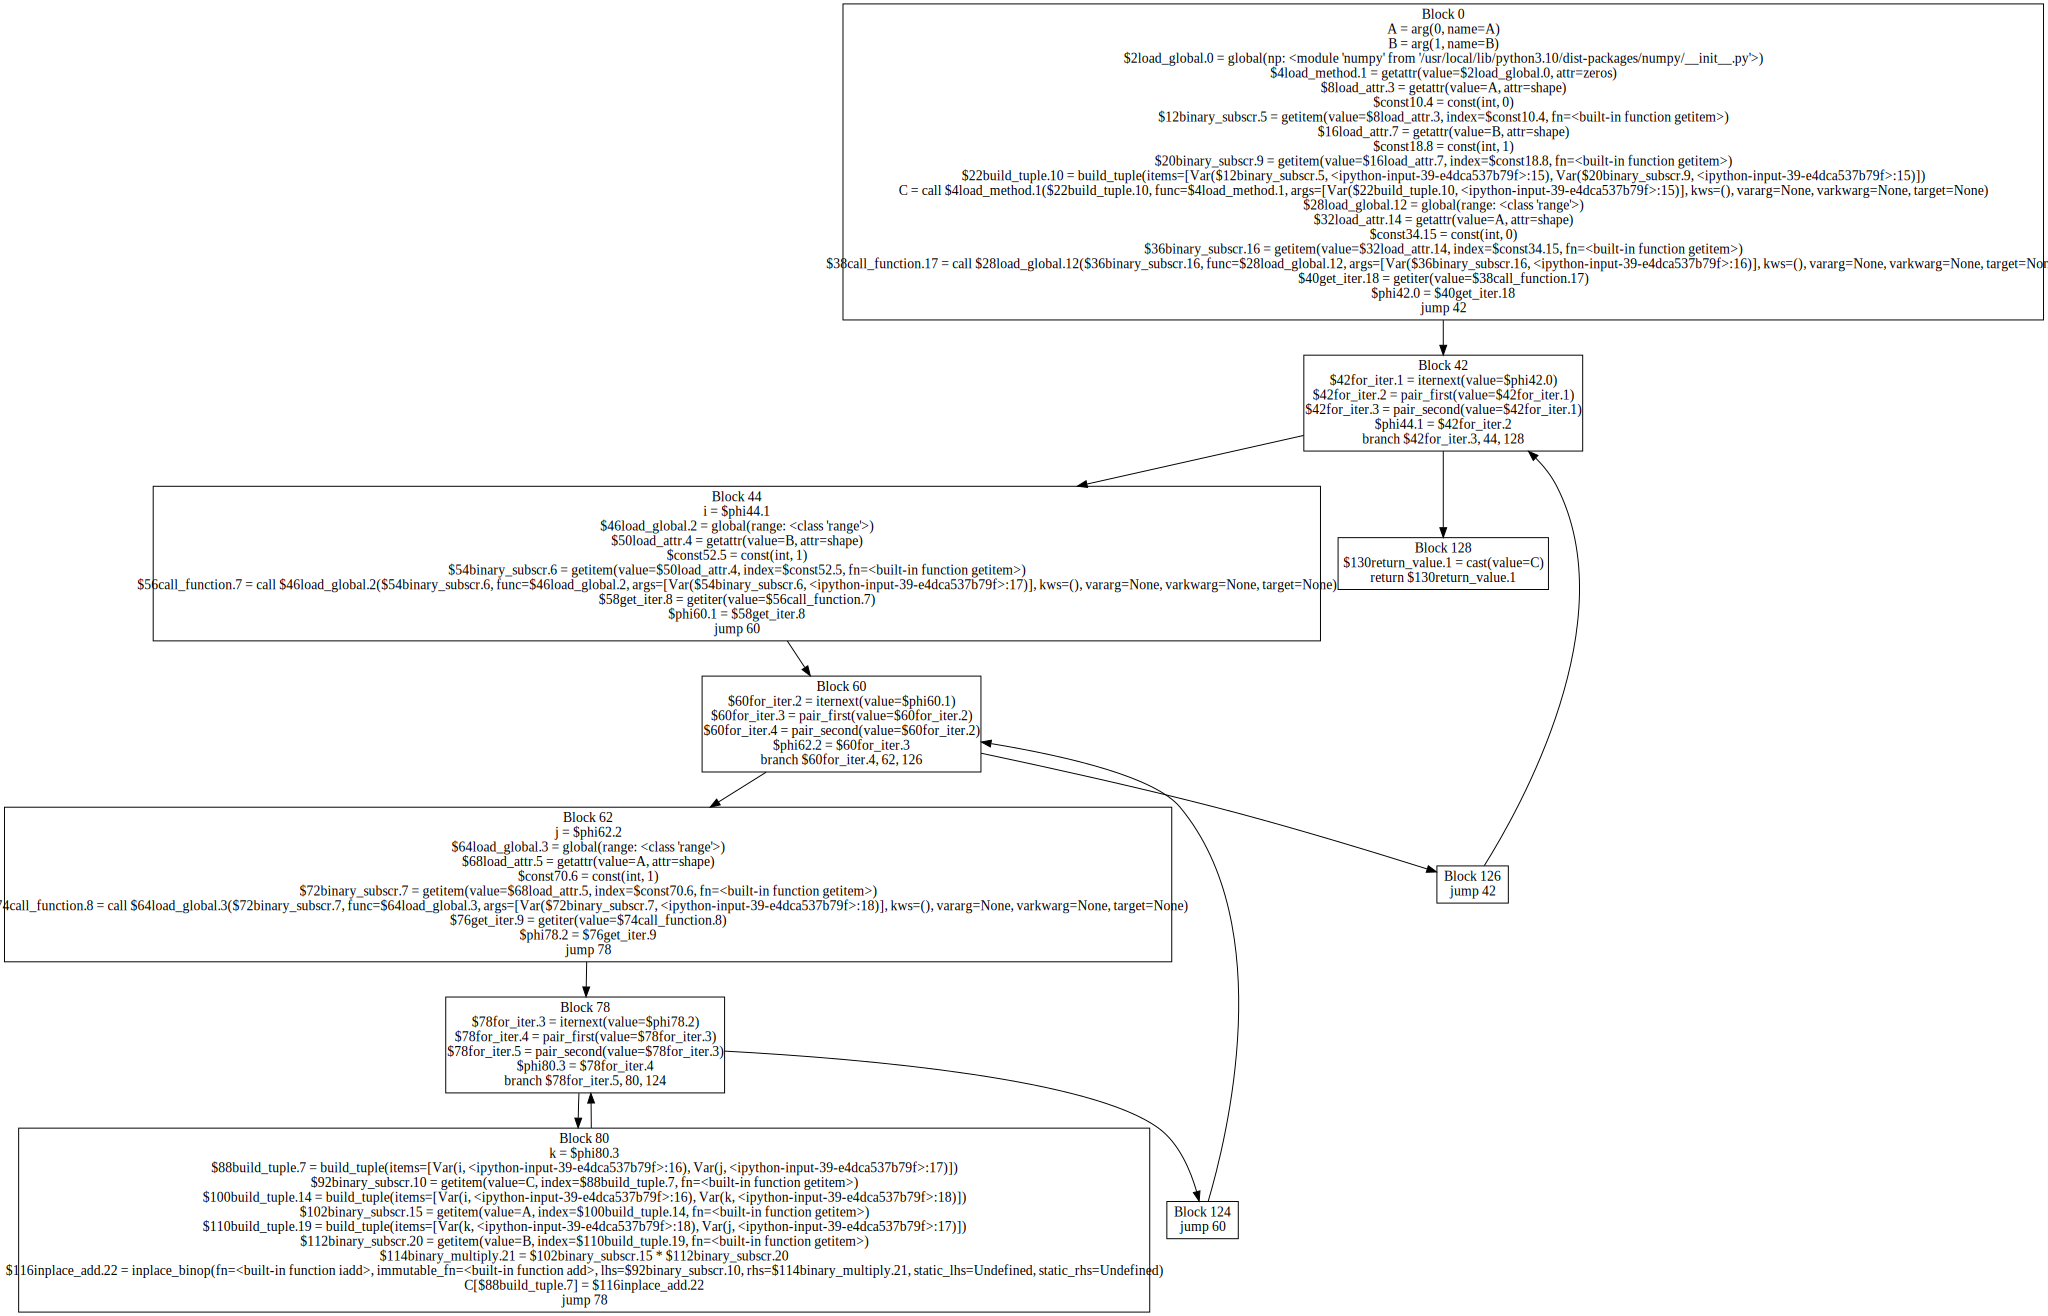

AST Tree: Module(
    body=[
        FunctionDef(
            name='matmul',
            args=arguments(
                posonlyargs=[],
                args=[
                    arg(arg='A'),
                    arg(arg='B')],
                kwonlyargs=[],
                kw_defaults=[],
                defaults=[]),
            body=[
                Expr(
                    value=Constant(value='\n    Perform a matrix multiplication.\n\n    Args:\n        A: A numpy array representing the first matrix.\n        B: A numpy array representing the second matrix.\n\n    Returns:\n        The result of the matrix multiplication.\n    ')),
                Assign(
                    targets=[
                        Name(id='C', ctx=Store())],
                    value=Call(
                        func=Attribute(
                            value=Name(id='np', ctx=Load()),
                            attr='zeros',
                            ctx=Load()),
                        args=[

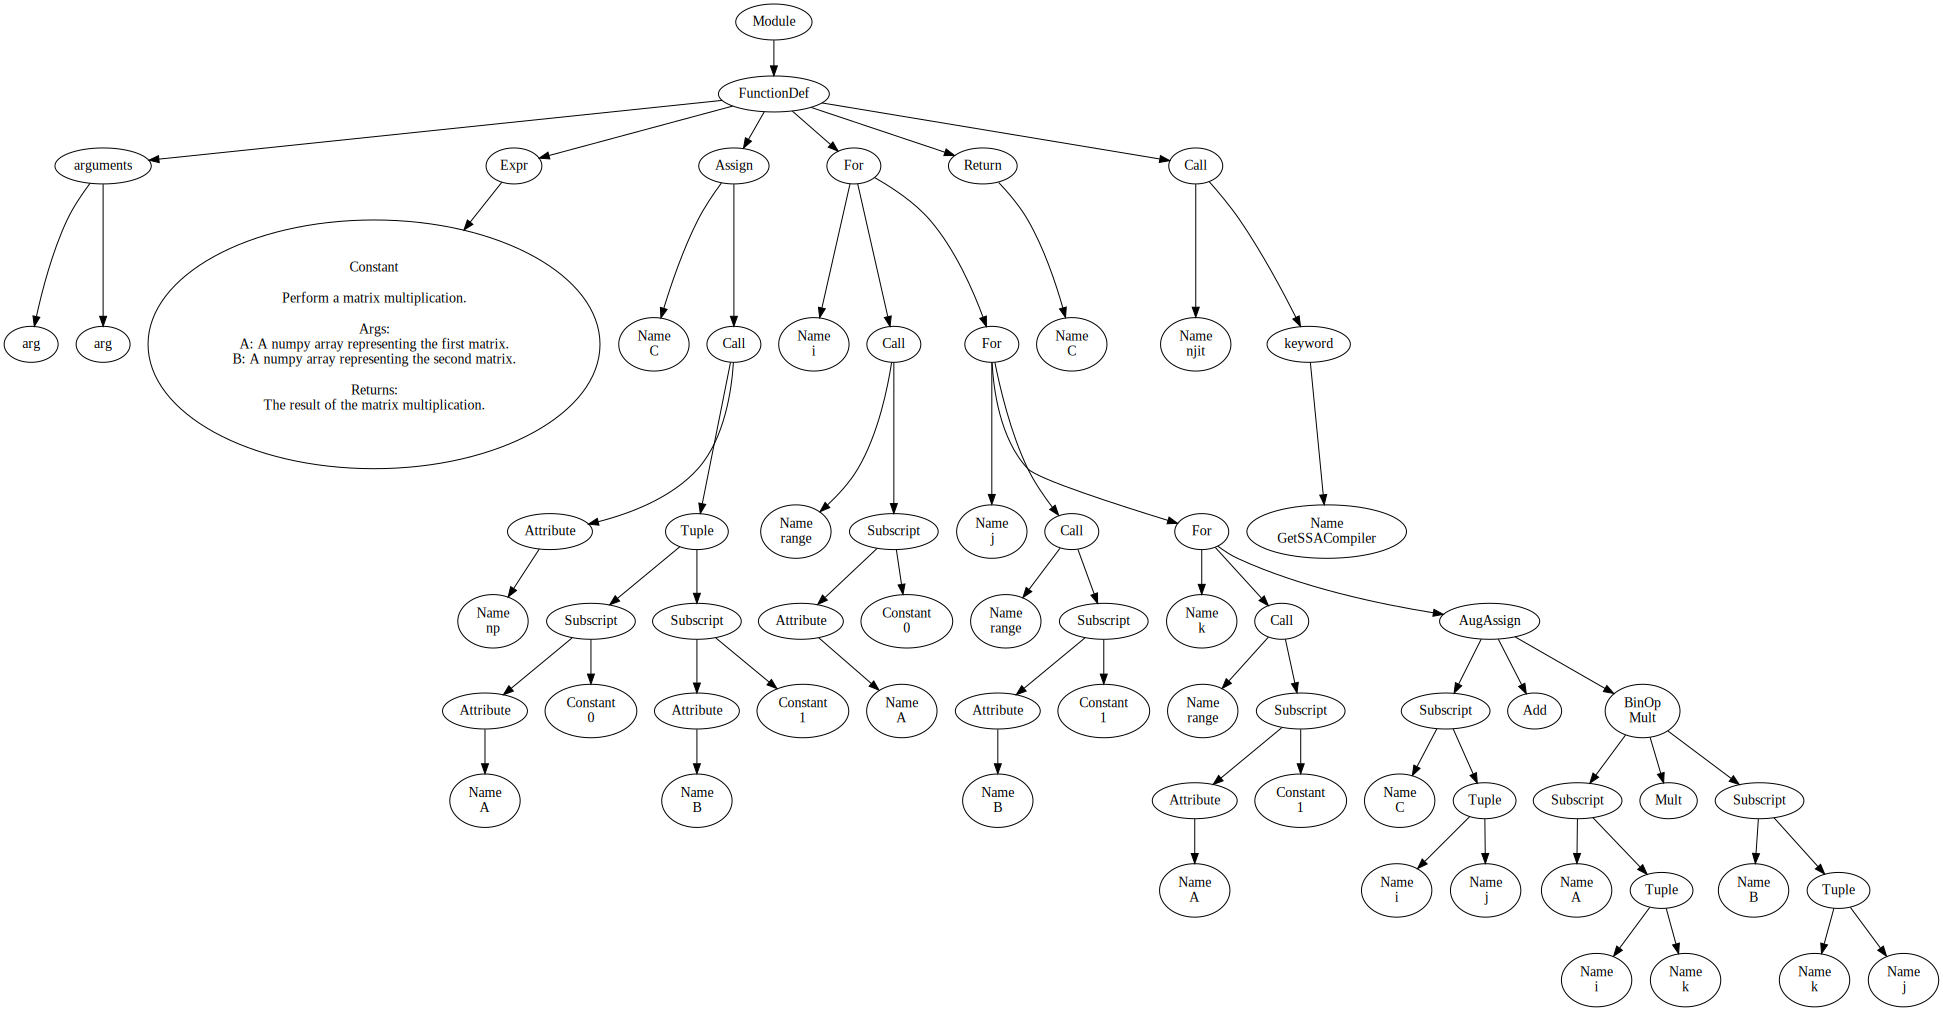

In [39]:
import numpy as np

@njit(pipeline_class=GetSSACompiler)
def matmul(A, B):
    """
    Perform a matrix multiplication.

    Args:
        A: A numpy array representing the first matrix.
        B: A numpy array representing the second matrix.

    Returns:
        The result of the matrix multiplication.
    """
    C = np.zeros((A.shape[0], B.shape[1]))
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            for k in range(A.shape[1]):
                C[i, j] += A[i, k] * B[k, j]
    return C

ssa_by_blocks.clear()
blocks.clear()
func_ir = None

matmul(np.zeros((2, 2)), np.zeros((2, 2)))
print("SSA Statements Grouped by Block:")
for blk_offset, ssa_list in ssa_by_blocks.items():
  print(f"Block {blk_offset}:")
  for stmt in ssa_list:
    print(f"  {stmt}")
print()

cfg_viz(blocks)

display(visualize_ast(get_ast(matmul)))